▶ Plotting branching process ...
▶ Plotting R0 threshold ...
▶ Plotting SIR model ...
▶ Plotting SIS model ...
▶ Plotting percolation curves ...
▶ Plotting network snapshot ...
▶ Plotting network SIR comparison ...


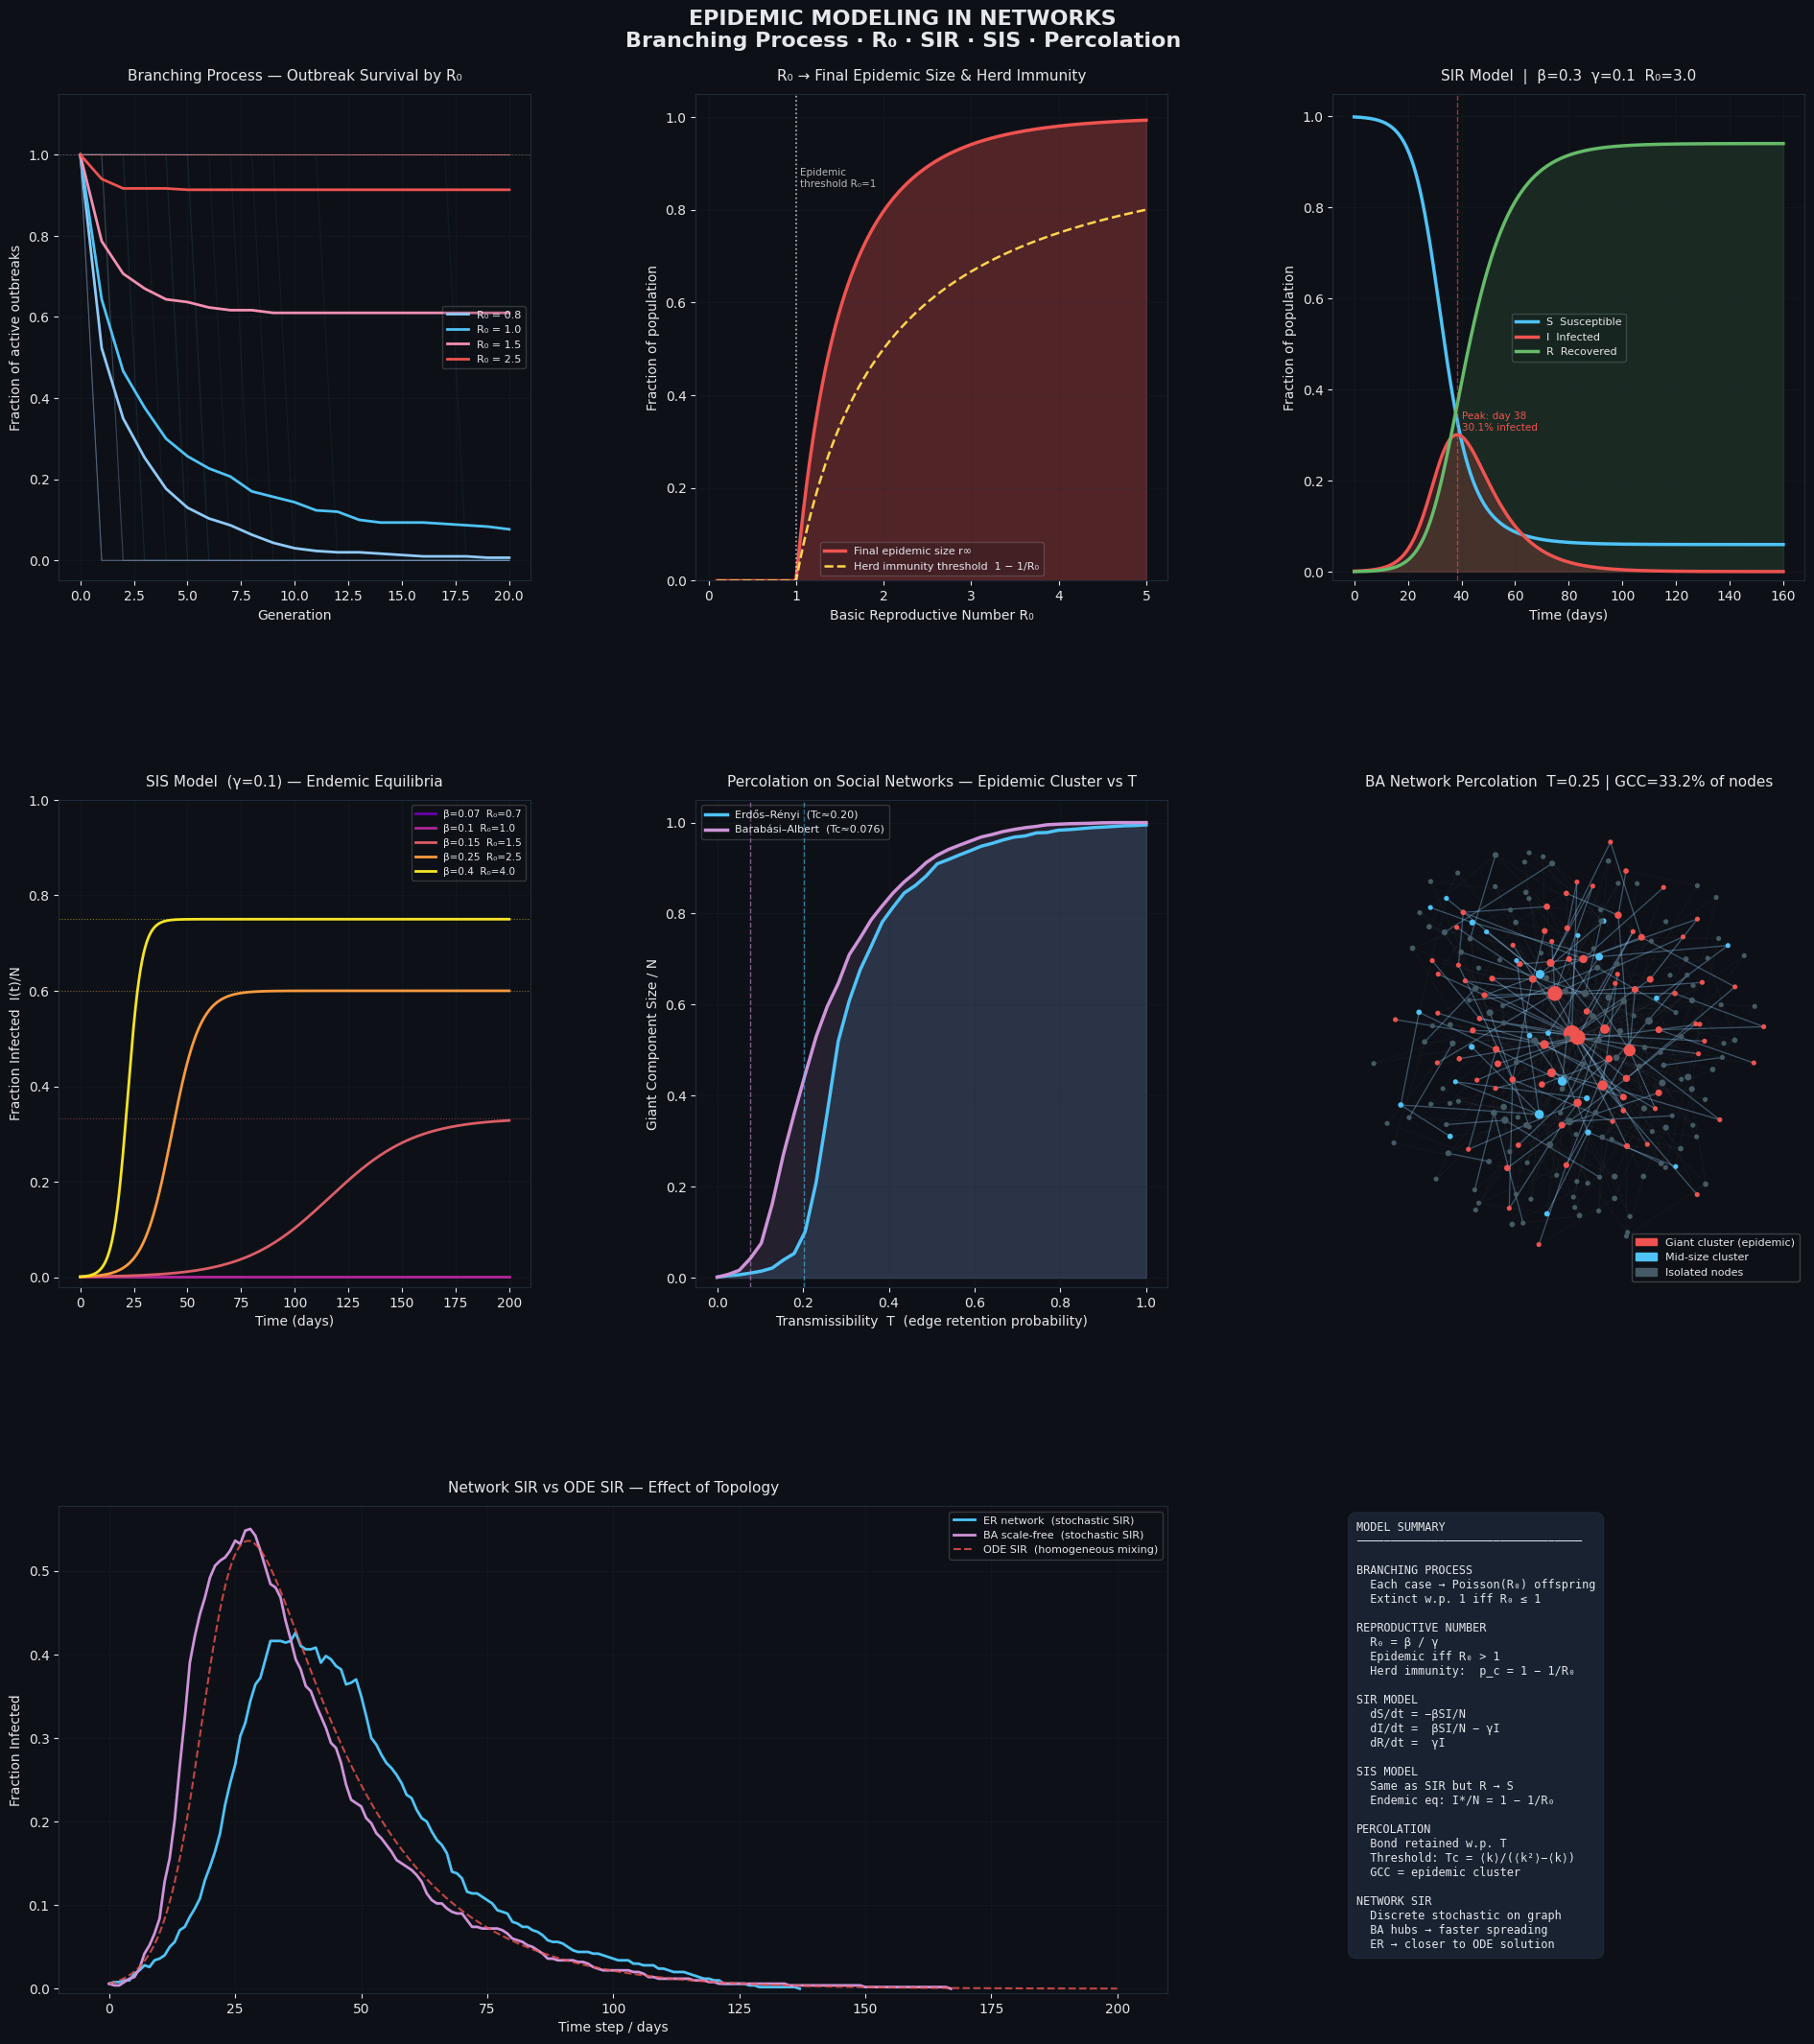

In [2]:
"""
=============================================================================
  EPIDEMIC MODELING IN NETWORKS — A Computational Illustration
=============================================================================
  Topics Covered:
    1. Simple Branching Process
    2. Reproductive Number (R0)
    3. SIR Model (Susceptible → Infected → Recovered)
    4. SIS Model (Susceptible → Infected → Susceptible)
    5. Percolation Model on Social Networks

  Each section is self-contained with:
    - Definitions and formulae as comments
    - Simulation / numerical solution code
    - Visualization
=============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy.integrate import odeint
import networkx as nx
import random
from collections import Counter

# ── Styling ──────────────────────────────────────────────────────────────────
plt.style.use("dark_background")
PALETTE = {
    "S": "#4FC3F7",   # Susceptible  – sky blue
    "I": "#EF5350",   # Infected     – vivid red
    "R": "#66BB6A",   # Recovered    – green
    "bg": "#0D1117",  # Figure background
    "grid": "#1F2937",
    "text": "#E5E7EB",
}
plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"],
    "axes.facecolor":   PALETTE["bg"],
    "axes.edgecolor":   PALETTE["grid"],
    "axes.labelcolor":  PALETTE["text"],
    "xtick.color":      PALETTE["text"],
    "ytick.color":      PALETTE["text"],
    "text.color":       PALETTE["text"],
    "grid.color":       PALETTE["grid"],
    "grid.linewidth":   0.5,
})


# ═════════════════════════════════════════════════════════════════════════════
#  SECTION 1 — SIMPLE BRANCHING PROCESS
# ═════════════════════════════════════════════════════════════════════════════
"""
BRANCHING PROCESS (Galton–Watson model)
---------------------------------------
Each infected individual independently infects a random number of new people
drawn from a fixed offspring distribution (here: Poisson with mean R0).

Key quantity:
  R0 = mean offspring = E[Z]   (Reproductive Number)

Extinction probability q satisfies the fixed-point equation:
  q = G(q)   where  G(s) = E[s^Z]  is the probability-generating function.

For Poisson offspring: G(s) = exp(R0 * (s − 1))
  → If R0 ≤ 1 : q = 1  (certain extinction)
  → If R0 > 1 : q < 1  (positive probability of an epidemic)

Generation k population: Z_k  (random, depends on R0 and stochasticity)
"""

def branching_process(R0: float, max_gen: int = 20, n_simulations: int = 200,
                       seed: int = 42) -> list:
    """
    Simulate the Galton–Watson branching process.

    Parameters
    ----------
    R0           : mean offspring (Reproductive Number)
    max_gen      : maximum number of generations to simulate
    n_simulations: number of independent epidemic trajectories
    seed         : random seed for reproducibility

    Returns
    -------
    List of arrays; each array is the population size per generation
    for one simulation run.
    """
    rng = np.random.default_rng(seed)
    all_runs = []

    for _ in range(n_simulations):
        pop = [1]  # generation 0: single index case
        for gen in range(1, max_gen + 1):
            current_infected = pop[-1]
            if current_infected == 0:
                pop.append(0)
                continue
            # Each individual produces Poisson(R0) offspring (new infections)
            # Formula: Z_{k+1} = sum_{i=1}^{Z_k} X_i,  X_i ~ Poisson(R0)
            new_infections = rng.poisson(R0, size=current_infected).sum()
            pop.append(new_infections)
        all_runs.append(np.array(pop))

    return all_runs


def plot_branching_process(ax, R0_values=(0.8, 1.0, 1.5, 2.5)):
    """Plot mean trajectories and extinction probability vs R0."""
    colors = ["#90CAF9", "#4FC3F7", "#F48FB1", "#EF5350"]
    max_gen = 20

    for R0, col in zip(R0_values, colors):
        runs = branching_process(R0, max_gen=max_gen, n_simulations=300)

        # Fraction of runs still active (not extinct) at each generation
        active = np.array([[1 if g > 0 else 0 for g in run] for run in runs])
        mean_active = active.mean(axis=0)

        gens = np.arange(max_gen + 1)
        ax.plot(gens, mean_active, color=col, lw=2,
                label=f"R₀ = {R0}")

        # Plot a few individual stochastic runs (faint)
        for run in runs[:15]:
            ax.plot(gens, (run > 0).astype(float), color=col,
                    alpha=0.06, lw=0.8)

    ax.axhline(1.0, color="white", lw=0.5, ls="--", alpha=0.3)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fraction of active outbreaks")
    ax.set_title("Branching Process — Outbreak Survival by R₀", fontsize=11, pad=10)
    ax.legend(framealpha=0.2, fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.15)


# ═════════════════════════════════════════════════════════════════════════════
#  SECTION 2 — REPRODUCTIVE NUMBER R0 AND EPIDEMIC THRESHOLD
# ═════════════════════════════════════════════════════════════════════════════
"""
REPRODUCTIVE NUMBER (R0)
------------------------
R0 = average number of secondary infections caused by ONE infectious individual
     in a FULLY susceptible population.

Relationship to SIR parameters:
   R0 = β / γ

where:
   β = transmission rate (per infected per susceptible per time unit)
   γ = recovery rate (= 1 / infectious period)

Epidemic threshold:
   R0 < 1  → epidemic dies out
   R0 = 1  → endemic boundary (critical point)
   R0 > 1  → epidemic grows

Effective reproductive number Rt at time t:
   Rt = R0 · S(t) / N
(as susceptible pool depletes, Rt decreases below R0)

Herd immunity threshold (fraction that must be immune):
   p_c = 1 − 1/R0
"""

def plot_R0_threshold(ax):
    """
    Visualise final epidemic size as a function of R0 using
    the implicit equation:
        r∞ = 1 − exp(−R0 · r∞)   (SIR final-size relation)
    """
    R0_range = np.linspace(0.1, 5.0, 400)
    final_sizes = []

    for R0 in R0_range:
        # Solve fixed point: r = 1 − exp(−R0 * r)   via iteration
        r = 0.5  # initial guess
        for _ in range(500):
            r_new = 1 - np.exp(-R0 * r)
            if abs(r_new - r) < 1e-9:
                break
            r = r_new
        final_sizes.append(r if R0 > 1 else 0.0)

    ax.fill_between(R0_range, 0, final_sizes, alpha=0.3, color=PALETTE["I"])
    ax.plot(R0_range, final_sizes, color=PALETTE["I"], lw=2.5,
            label="Final epidemic size r∞")

    # Herd immunity threshold line
    p_c = [max(0, 1 - 1/R0) for R0 in R0_range]
    ax.plot(R0_range, p_c, color="#FFD54F", lw=1.8, ls="--",
            label="Herd immunity threshold  1 − 1/R₀")

    ax.axvline(1.0, color="white", lw=1.2, ls=":", alpha=0.7)
    ax.text(1.05, 0.85, "Epidemic\nthreshold R₀=1",
            color="white", fontsize=7.5, alpha=0.7)

    ax.set_xlabel("Basic Reproductive Number R₀")
    ax.set_ylabel("Fraction of population")
    ax.set_title("R₀ → Final Epidemic Size & Herd Immunity", fontsize=11, pad=10)
    ax.legend(framealpha=0.2, fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)


# ═════════════════════════════════════════════════════════════════════════════
#  SECTION 3 — SIR MODEL
# ═════════════════════════════════════════════════════════════════════════════
"""
SIR MODEL — Kermack & McKendrick (1927)
----------------------------------------
Compartments:
  S(t) — Susceptible: can catch the disease
  I(t) — Infected:    infectious to others
  R(t) — Recovered:   immune (or deceased), no longer infectious

Conservation: S + I + R = N  (constant population)

Differential equations (continuous, deterministic):
  dS/dt = −β · S · I / N        (mass-action mixing)
  dI/dt =  β · S · I / N − γ·I
  dR/dt =  γ · I

Parameters:
  β  [day⁻¹] — effective contact rate × transmission probability
  γ  [day⁻¹] — recovery rate = 1 / (mean infectious period)
  R0 = β / γ

The epidemic peaks when S(t) = N/R0  (inflection of I curve).
"""

def sir_ode(y, t, beta, gamma, N):
    """
    ODE right-hand side for the SIR model.

    y     : [S, I, R]
    t     : time point (required by odeint signature)
    beta  : transmission rate
    gamma : recovery rate
    N     : total population
    """
    S, I, R = y
    dS = -beta * S * I / N
    dI =  beta * S * I / N - gamma * I
    dR =  gamma * I
    return [dS, dI, dR]


def solve_sir(N=10_000, I0=10, beta=0.3, gamma=0.1, t_max=160):
    """Numerically solve SIR ODEs using scipy.integrate.odeint."""
    S0 = N - I0
    R0_val = 0
    y0 = [S0, I0, R0_val]
    t = np.linspace(0, t_max, t_max * 4)
    sol = odeint(sir_ode, y0, t, args=(beta, gamma, N))
    return t, sol


def plot_sir(ax, beta=0.3, gamma=0.1, N=10_000):
    """Plot SIR compartment curves."""
    t, sol = solve_sir(N=N, beta=beta, gamma=gamma)
    R0 = beta / gamma

    ax.fill_between(t, sol[:, 2] / N, alpha=0.15, color=PALETTE["R"])
    ax.fill_between(t, sol[:, 1] / N, alpha=0.2,  color=PALETTE["I"])

    ax.plot(t, sol[:, 0] / N, color=PALETTE["S"],  lw=2.5, label="S  Susceptible")
    ax.plot(t, sol[:, 1] / N, color=PALETTE["I"],  lw=2.5, label="I  Infected")
    ax.plot(t, sol[:, 2] / N, color=PALETTE["R"],  lw=2.5, label="R  Recovered")

    # Peak infection line
    peak_day = t[np.argmax(sol[:, 1])]
    peak_val = sol[:, 1].max() / N
    ax.axvline(peak_day, color=PALETTE["I"], lw=1, ls="--", alpha=0.6)
    ax.text(peak_day + 2, peak_val + 0.01,
            f"Peak: day {peak_day:.0f}\n{peak_val*100:.1f}% infected",
            color=PALETTE["I"], fontsize=7.5)

    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Fraction of population")
    ax.set_title(f"SIR Model  |  β={beta}  γ={gamma}  R₀={R0:.1f}", fontsize=11, pad=10)
    ax.legend(framealpha=0.2, fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.02, 1.05)


# ═════════════════════════════════════════════════════════════════════════════
#  SECTION 4 — SIS MODEL
# ═════════════════════════════════════════════════════════════════════════════
"""
SIS MODEL — Endemic diseases (no lasting immunity)
----------------------------------------------------
Recovered individuals return to susceptible pool (e.g. flu, gonorrhoea).

Compartments: S and I only  (R → S immediately upon recovery)

Differential equations:
  dS/dt = −β · S · I / N  +  γ · I
  dI/dt =  β · S · I / N  −  γ · I

Endemic equilibrium (if R0 > 1):
  I* / N = 1 − 1/R0   (fraction infected at steady state)
  S* / N = 1 / R0

Behaviour:
  R0 < 1 → disease-free equilibrium  (I → 0)
  R0 > 1 → endemic equilibrium       (I → I*)
"""

def sis_ode(y, t, beta, gamma, N):
    """ODE right-hand side for the SIS model."""
    S, I = y
    dS = -beta * S * I / N + gamma * I
    dI =  beta * S * I / N - gamma * I
    return [dS, dI]


def solve_sis(N=10_000, I0=10, beta=0.3, gamma=0.1, t_max=200):
    """Numerically solve SIS ODEs."""
    S0 = N - I0
    y0 = [S0, I0]
    t = np.linspace(0, t_max, t_max * 4)
    sol = odeint(sis_ode, y0, t, args=(beta, gamma, N))
    return t, sol


def plot_sis(ax, gamma=0.1, N=10_000):
    """Plot SIS for multiple beta values showing sub/super-critical behaviour."""
    betas = [0.07, 0.10, 0.15, 0.25, 0.40]
    cmap  = plt.cm.plasma(np.linspace(0.2, 0.95, len(betas)))

    for beta, col in zip(betas, cmap):
        R0 = beta / gamma
        t, sol = solve_sis(N=N, beta=beta, gamma=gamma)
        I_frac = sol[:, 1] / N
        ax.plot(t, I_frac, color=col, lw=2,
                label=f"β={beta}  R₀={R0:.1f}")

        # Endemic equilibrium dashed line
        if R0 > 1:
            eq = 1 - 1 / R0
            ax.axhline(eq, color=col, lw=0.8, ls=":", alpha=0.5)

    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Fraction Infected  I(t)/N")
    ax.set_title(f"SIS Model  (γ={gamma}) — Endemic Equilibria", fontsize=11, pad=10)
    ax.legend(framealpha=0.2, fontsize=7.5, ncol=1)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.02, 1.0)


# ═════════════════════════════════════════════════════════════════════════════
#  SECTION 5 — PERCOLATION MODEL ON SOCIAL NETWORKS
# ═════════════════════════════════════════════════════════════════════════════
"""
BOND PERCOLATION MODEL
-----------------------
Each edge of a network is "open" (disease spreads along it) with probability
T (transmissibility), or "closed" with probability 1 − T.

The giant connected component (GCC) of open edges = the potential epidemic cluster.

Percolation threshold Tc:
  For a random graph with mean degree <k> and second moment <k²>:
      Tc = <k> / (<k²> − <k>)   (Molloy–Reed criterion)

Interpretation:
  T < Tc : only small local outbreaks (sub-critical)
  T > Tc : a giant epidemic cluster spanning O(N) nodes (super-critical)

Simulation procedure:
  1. Build the social network (e.g. Erdős–Rényi, Barabási–Albert)
  2. For each edge, retain it with probability T  (bond percolation)
  3. Find connected components of the retained subgraph
  4. GCC size / N = epidemic fraction
"""

def percolation_simulation(G: nx.Graph, T: float, rng=None) -> float:
    """
    Bond percolation on graph G with transmissibility T.

    Returns the fraction of nodes in the Giant Connected Component (GCC).
    """
    if rng is None:
        rng = np.random.default_rng()

    # Keep each edge independently with probability T
    edges_to_keep = [(u, v) for u, v in G.edges()
                     if rng.random() < T]

    # Build subgraph from retained edges + all nodes
    subG = nx.Graph()
    subG.add_nodes_from(G.nodes())
    subG.add_edges_from(edges_to_keep)

    # Find largest connected component
    components = list(nx.connected_components(subG))
    if not components:
        return 0.0
    gcc_size = max(len(c) for c in components)
    return gcc_size / G.number_of_nodes()


def plot_percolation(ax, n=1000, n_trials=30, seed=0):
    """
    Plot GCC fraction vs transmissibility T for two network types:
      - Erdős–Rényi (ER): homogeneous degree distribution, sharp threshold
      - Barabási–Albert (BA): scale-free, lower effective threshold
    """
    rng = np.random.default_rng(seed)
    T_range = np.linspace(0.0, 1.0, 40)

    # --- Erdős–Rényi random graph  <k> ≈ 5 ---
    G_er = nx.erdos_renyi_graph(n, p=5 / n, seed=seed)
    k_er  = np.mean([d for _, d in G_er.degree()])
    k2_er = np.mean([d**2 for _, d in G_er.degree()])
    Tc_er = k_er / (k2_er - k_er) if k2_er > k_er else 1.0

    # --- Barabási–Albert scale-free graph  m=3 ---
    G_ba = nx.barabasi_albert_graph(n, m=3, seed=seed)
    k_ba  = np.mean([d for _, d in G_ba.degree()])
    k2_ba = np.mean([d**2 for _, d in G_ba.degree()])
    Tc_ba = k_ba / (k2_ba - k_ba) if k2_ba > k_ba else 1.0

    results = {"ER": [], "BA": []}
    for T in T_range:
        gcc_er = [percolation_simulation(G_er, T, rng) for _ in range(n_trials)]
        gcc_ba = [percolation_simulation(G_ba, T, rng) for _ in range(n_trials)]
        results["ER"].append(np.mean(gcc_er))
        results["BA"].append(np.mean(gcc_ba))

    ax.plot(T_range, results["ER"], color="#4FC3F7", lw=2.5,
            label=f"Erdős–Rényi  (Tc≈{Tc_er:.2f})")
    ax.fill_between(T_range, 0, results["ER"], alpha=0.12, color="#4FC3F7")

    ax.plot(T_range, results["BA"], color="#CE93D8", lw=2.5,
            label=f"Barabási–Albert  (Tc≈{Tc_ba:.3f})")
    ax.fill_between(T_range, 0, results["BA"], alpha=0.12, color="#CE93D8")

    ax.axvline(Tc_er, color="#4FC3F7", lw=1, ls="--", alpha=0.6)
    ax.axvline(Tc_ba, color="#CE93D8", lw=1, ls="--", alpha=0.6)

    ax.set_xlabel("Transmissibility  T  (edge retention probability)")
    ax.set_ylabel("Giant Component Size / N")
    ax.set_title("Percolation on Social Networks — Epidemic Cluster vs T",
                 fontsize=11, pad=10)
    ax.legend(framealpha=0.2, fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.02, 1.05)


def plot_network_snapshot(ax, n=200, T=0.3, seed=7):
    """
    Draw a BA network coloured by percolation cluster membership.
    Largest cluster = epidemic (red), others = minor outbreaks (blue), isolated = grey.
    """
    rng = np.random.default_rng(seed)
    G   = nx.barabasi_albert_graph(n, m=2, seed=seed)

    edges_kept = [(u, v) for u, v in G.edges() if rng.random() < T]
    subG = nx.Graph()
    subG.add_nodes_from(G.nodes())
    subG.add_edges_from(edges_kept)

    components = sorted(nx.connected_components(subG), key=len, reverse=True)
    node_color = {}
    for idx, comp in enumerate(components):
        if idx == 0:
            col = PALETTE["I"]          # largest = epidemic
        elif len(comp) > 3:
            col = PALETTE["S"]          # medium clusters = at-risk
        else:
            col = "#455A64"             # tiny = isolated
        for node in comp:
            node_color[node] = col

    colors  = [node_color[n] for n in G.nodes()]
    pos     = nx.spring_layout(G, seed=seed, k=0.4)
    sizes   = [8 + G.degree(n) * 3 for n in G.nodes()]

    # Draw original edges (faint)
    nx.draw_networkx_edges(G, pos, ax=ax,
                           alpha=0.05, width=0.4, edge_color="white")
    # Draw retained edges
    nx.draw_networkx_edges(subG, pos, ax=ax,
                           edgelist=edges_kept,
                           alpha=0.35, width=0.9, edge_color="#90CAF9")
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=colors, node_size=sizes, linewidths=0)

    gcc_frac = len(components[0]) / n if components else 0
    ax.set_title(
        f"BA Network Percolation  T={T} | GCC={gcc_frac*100:.1f}% of nodes",
        fontsize=11, pad=10
    )
    # Legend patches
    patches = [
        mpatches.Patch(color=PALETTE["I"], label="Giant cluster (epidemic)"),
        mpatches.Patch(color=PALETTE["S"], label="Mid-size cluster"),
        mpatches.Patch(color="#455A64",    label="Isolated nodes"),
    ]
    ax.legend(handles=patches, framealpha=0.25, fontsize=8, loc="lower right")
    ax.axis("off")


# ═════════════════════════════════════════════════════════════════════════════
#  SECTION 6 — STOCHASTIC SIR ON A NETWORK (ABM-lite)
# ═════════════════════════════════════════════════════════════════════════════
"""
NETWORK SIR SIMULATION
-----------------------
Rather than assuming homogeneous mixing (ODE SIR),
we simulate on an explicit contact network.

At each time step for each infected node i:
  For each susceptible neighbour j:
      j gets infected with probability β_per_contact

Infected nodes recover with probability γ per time step.

This captures network heterogeneity:
  - Hubs (high-degree nodes) accelerate spreading
  - Clustered networks slow spreading vs ODE prediction
"""

def network_sir(G: nx.Graph, beta: float, gamma: float,
                initial_infected: int = 3, seed: int = 0) -> dict:
    """
    Stochastic SIR simulation on a contact network G.

    Returns dict with lists of S, I, R counts per time step.
    """
    rng = np.random.default_rng(seed)
    state = {node: "S" for node in G.nodes()}

    # Seed initial infections
    seeds = rng.choice(list(G.nodes()), size=initial_infected, replace=False)
    for s in seeds:
        state[s] = "I"

    history = {"S": [], "I": [], "R": []}
    N = G.number_of_nodes()

    while True:
        counts = Counter(state.values())
        history["S"].append(counts.get("S", 0))
        history["I"].append(counts.get("I", 0))
        history["R"].append(counts.get("R", 0))

        if counts.get("I", 0) == 0:
            break

        new_state = dict(state)

        for node in G.nodes():
            if state[node] == "I":
                # Attempt to infect susceptible neighbours
                for nbr in G.neighbors(node):
                    if state[nbr] == "S" and rng.random() < beta:
                        new_state[nbr] = "I"
                # Recovery
                if rng.random() < gamma:
                    new_state[node] = "R"

        state = new_state

    return history


def plot_network_sir(ax, seed=42):
    """
    Compare ODE SIR vs network SIR on BA and ER graphs.
    """
    N, beta, gamma = 500, 0.06, 0.05

    G_er = nx.erdos_renyi_graph(N, p=5/N, seed=seed)
    G_ba = nx.barabasi_albert_graph(N, m=3, seed=seed)

    hist_er = network_sir(G_er, beta, gamma, seed=seed)
    hist_ba = network_sir(G_ba, beta, gamma, seed=seed)

    # ODE reference
    t_ode, sol_ode = solve_sir(N=N, I0=3, beta=beta * 5, gamma=gamma, t_max=200)

    ax.plot(np.array(hist_er["I"]) / N, color="#4FC3F7", lw=2,
            label="ER network  (stochastic SIR)")
    ax.plot(np.array(hist_ba["I"]) / N, color="#CE93D8", lw=2,
            label="BA scale-free  (stochastic SIR)")
    ax.plot(t_ode, sol_ode[:, 1] / N, color=PALETTE["I"], lw=1.5,
            ls="--", alpha=0.8, label="ODE SIR  (homogeneous mixing)")

    ax.set_xlabel("Time step / days")
    ax.set_ylabel("Fraction Infected")
    ax.set_title("Network SIR vs ODE SIR — Effect of Topology", fontsize=11, pad=10)
    ax.legend(framealpha=0.2, fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.005, None)


# ═════════════════════════════════════════════════════════════════════════════
#  MAIN — BUILD & SAVE THE FIGURE
# ═════════════════════════════════════════════════════════════════════════════

def main():
    fig = plt.figure(figsize=(20, 22), facecolor=PALETTE["bg"])
    fig.suptitle(
        "EPIDEMIC MODELING IN NETWORKS\n"
        "Branching Process · R₀ · SIR · SIS · Percolation",
        fontsize=16, fontweight="bold", color=PALETTE["text"],
        y=0.98
    )

    gs = gridspec.GridSpec(
        3, 3,
        figure=fig,
        hspace=0.45, wspace=0.35,
        top=0.94, bottom=0.04,
        left=0.06, right=0.97
    )

    # Row 0
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[0, 2])

    # Row 1
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])
    ax5 = fig.add_subplot(gs[1, 2])

    # Row 2
    ax6 = fig.add_subplot(gs[2, 0:2])
    ax7 = fig.add_subplot(gs[2, 2])

    print("▶ Plotting branching process ...")
    plot_branching_process(ax0)

    print("▶ Plotting R0 threshold ...")
    plot_R0_threshold(ax1)

    print("▶ Plotting SIR model ...")
    plot_sir(ax2)

    print("▶ Plotting SIS model ...")
    plot_sis(ax3)

    print("▶ Plotting percolation curves ...")
    plot_percolation(ax4, n=800, n_trials=20, seed=0)

    print("▶ Plotting network snapshot ...")
    plot_network_snapshot(ax5, n=250, T=0.25, seed=42)

    print("▶ Plotting network SIR comparison ...")
    plot_network_sir(ax6, seed=7)

    # ── Summary panel ────────────────────────────────────────────────────────
    ax7.axis("off")
    summary = (
        "MODEL SUMMARY\n"
        "─────────────────────────────────\n\n"
        "BRANCHING PROCESS\n"
        "  Each case → Poisson(R₀) offspring\n"
        "  Extinct w.p. 1 iff R₀ ≤ 1\n\n"
        "REPRODUCTIVE NUMBER\n"
        "  R₀ = β / γ\n"
        "  Epidemic iff R₀ > 1\n"
        "  Herd immunity:  p_c = 1 − 1/R₀\n\n"
        "SIR MODEL\n"
        "  dS/dt = −βSI/N\n"
        "  dI/dt =  βSI/N − γI\n"
        "  dR/dt =  γI\n\n"
        "SIS MODEL\n"
        "  Same as SIR but R → S\n"
        "  Endemic eq: I*/N = 1 − 1/R₀\n\n"
        "PERCOLATION\n"
        "  Bond retained w.p. T\n"
        "  Threshold: Tc = ⟨k⟩/(⟨k²⟩−⟨k⟩)\n"
        "  GCC = epidemic cluster\n\n"
        "NETWORK SIR\n"
        "  Discrete stochastic on graph\n"
        "  BA hubs → faster spreading\n"
        "  ER → closer to ODE solution"
    )
    ax7.text(
        0.05, 0.97, summary,
        transform=ax7.transAxes,
        va="top", ha="left",
        fontsize=8.5,
        fontfamily="monospace",
        color=PALETTE["text"],
        bbox=dict(boxstyle="round,pad=0.7",
                  facecolor="#1A2535", edgecolor=PALETTE["grid"], alpha=0.9)
    )


    fig.savefig('epidemic_models.png', dpi=140, bbox_inches='tight', facecolor=PALETTE["bg"])
    plt.show()


if __name__ == "__main__":
    main()